In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [5]:
df = pd.read_csv('features.csv')
X = df.drop(columns=['Global_active_power', 'datetime'])
y = df['Global_active_power']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [7]:
ols = LinearRegression()
ols.fit(X_train, y_train)
y_pred_ols = ols.predict(X_test)

In [13]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [11]:
def print_metrics(y_true, y_pred, model_name):
    print(f'--- {model_name} ---')
    print(f'MAE: {mean_absolute_error(y_true, y_pred):.3f}')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.3f}')
    print(f'R2: {r2_score(y_true, y_pred):.3f}\n')

In [12]:
print_metrics(y_test, y_pred_ols, 'OLS')
print_metrics(y_test, y_pred_rf, 'Random Forest')

--- OLS ---
MAE: 0.009
RMSE: 0.013
R2: 1.000

--- Random Forest ---
MAE: 0.000
RMSE: 0.001
R2: 1.000



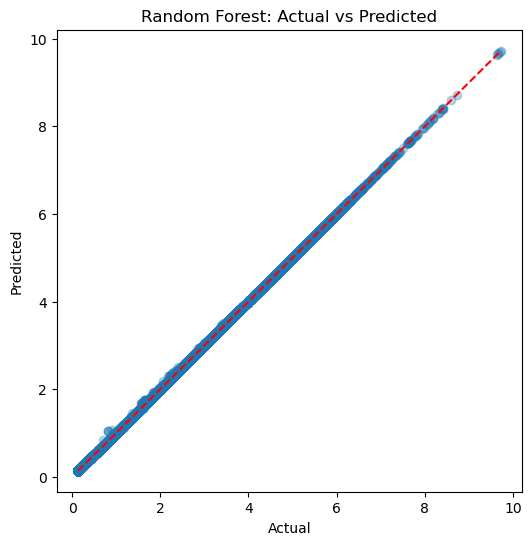

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest: Actual vs Predicted')
plt.show()

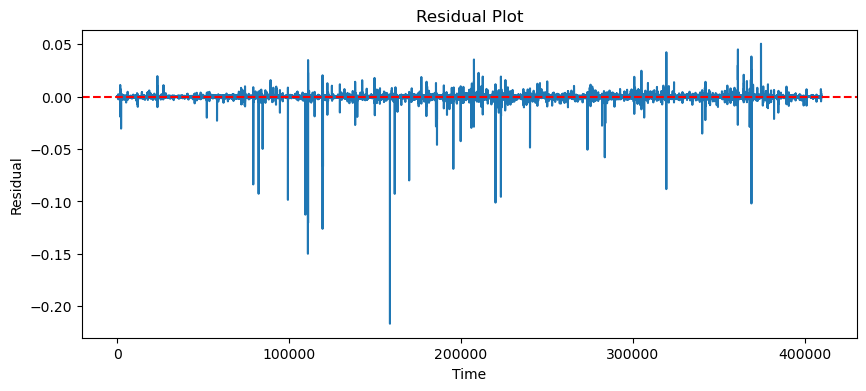

In [15]:
residuals = y_test - y_pred_rf
plt.figure(figsize=(10, 4))
plt.plot(residuals.values)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Time')
plt.ylabel('Residual')
plt.show()

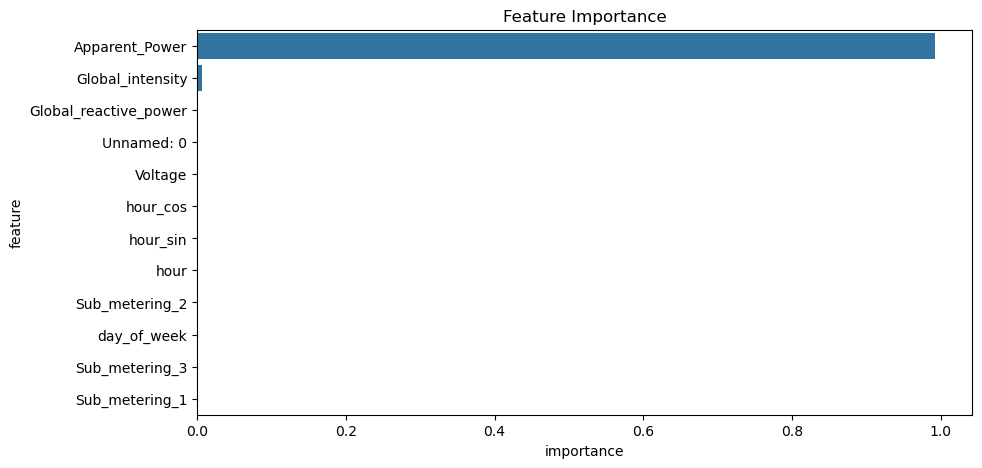

In [16]:
importances = rf.feature_importances_
feat_df = pd.DataFrame({'feature': X.columns, 'importance': importances})
feat_df.sort_values(by='importance', ascending=False, inplace=True)
plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=feat_df)
plt.title('Feature Importance')
plt.show()